# 07 — Pipeline live de actualización del Mundial 2026

**Proyecto:** D10Sformer — MIA305 (UdeSA, 2026)  
**Fase:** 7 — Predicciones dinámicas: re-simular condicionado a resultados reales

## Objetivo

1. **Optimizar el simulador** con `PrecomputedPredictor`: reduce 10K sims de **45 min → ~2-3 min** al precomputar los 2.256 pares posibles (48×47).
2. **API simple** para fijar resultados reales del Mundial:
   ```python
   fr = FixedResults()
   fr.add_group_match('Group_J', 'Argentina', 'Algeria', home_score=3, away_score=0)
   fr.add_knockout_result(match_id=89, winner='Argentina')
   ```
3. **Re-simulación condicionada**: las probabilidades se actualizan dado el estado real del torneo.
4. **Comparación deltas**: ¿cómo cambia P(Argentina campeón) después de cada partido?

## Cómo se usa en la práctica durante el Mundial

Cada vez que termine un partido (a partir del 11 de junio):

1. Agregás el resultado al `FixedResults`.
2. Corrés `monte_carlo(predictor, fixed_results=fr)` (~3 min).
3. Mirás las nuevas probabilidades.

Para Fase 8 podemos automatizar este flujo (scheduled task que lee resultados de una API y re-simula).

---
## 1. Setup

In [7]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/d10sformer'
except ImportError:
    import os
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/d10sformer


In [8]:
import sys, json, pickle, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(PROJECT_ROOT)
sys.path.insert(0, str(ROOT / 'src'))

DATA_INTERIM = ROOT / 'data' / 'interim'
REPORTS = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)

from simulation.bracket import WC2026_GROUPS, assert_bracket_consistency
from simulation.simulator import (
    monte_carlo, PrecomputedPredictor, FixedResults,
)
from data.feature_engineering import build_feature_matrix, get_feature_columns
from models.baselines import LogisticRegressionBaseline

assert_bracket_consistency()
print('✓ Bracket OK')

✓ Bracket OK


---
## 2. Cargar datos + entrenar LogReg (mismo flujo que Fase 6)

In [9]:
import math

df_int = pd.read_parquet(DATA_INTERIM / 'international_matches_with_elo.parquet')
df_int['date'] = pd.to_datetime(df_int['date'])
df_sorted = df_int.sort_values('date').reset_index(drop=True).copy()

# Rolling features (idéntico a Fase 4a/6)
team_history = defaultdict(list)
WINDOW = 5
def rmean(history, idx):
    recent = history[-WINDOW:]
    if not recent: return math.nan
    return sum(x[idx] for x in recent) / len(recent)

home_form, away_form, home_goals, away_goals = [], [], [], []
for _, row in df_sorted.iterrows():
    h, a = row.home_team, row.away_team
    hs, as_ = row.home_score, row.away_score
    home_form.append(rmean(team_history[h], 0))
    away_form.append(rmean(team_history[a], 0))
    home_goals.append(rmean(team_history[h], 1))
    away_goals.append(rmean(team_history[a], 1))
    if pd.notna(hs) and pd.notna(as_):
        if hs > as_:   h_pts, a_pts = 3, 0
        elif hs < as_: h_pts, a_pts = 0, 3
        else:          h_pts, a_pts = 1, 1
        team_history[h].append((h_pts, float(hs)))
        team_history[a].append((a_pts, float(as_)))
df_sorted['home_form_pts_5']     = home_form
df_sorted['away_form_pts_5']     = away_form
df_sorted['home_recent_goals_5'] = home_goals
df_sorted['away_recent_goals_5'] = away_goals

# Last state per team
WC_TEAMS = sorted({t for grp in WC2026_GROUPS.values() for t in grp})
def latest_state(team):
    rows = df_sorted[(df_sorted.home_team == team) | (df_sorted.away_team == team)]
    if len(rows) == 0: return None
    r = rows.iloc[-1]
    if r.home_team == team:
        return {'team': team, 'elo': float(r.home_elo_after) if pd.notna(r.home_elo_after) else float(r.home_elo_before),
                'form_pts': r.home_form_pts_5, 'recent_goals': r.home_recent_goals_5}
    return {'team': team, 'elo': float(r.away_elo_after) if pd.notna(r.away_elo_after) else float(r.away_elo_before),
            'form_pts': r.away_form_pts_5, 'recent_goals': r.away_recent_goals_5}

team_features = {}
for t in WC_TEAMS:
    st = latest_state(t)
    if st is None:
        team_features[t] = {'team': t, 'elo': 1500.0, 'form_pts': 1.0, 'recent_goals': 1.0}
    else:
        team_features[t] = st
print(f'✓ Features cargadas para {len(team_features)} equipos')

✓ Features cargadas para 48 equipos


In [10]:
from data.feature_engineering import build_feature_matrix, get_feature_columns, prepare_xy

# build_feature_matrix devuelve UN DataFrame con features + target
df_full = build_feature_matrix(
    df_sorted, windows_form=(5, 10), h2h_window=5, min_date='2014-01-01',
)
print(f'Feature DF: {df_full.shape}')

# prepare_xy separa features (X) y target (y), con one-hot de categóricas
X_full, y_full = prepare_xy(df_full, onehot_categoricals=True)
print(f'X: {X_full.shape}, y: {y_full.shape}')

logreg = LogisticRegressionBaseline()
logreg.fit(X_full, y_full)
FEATURE_COLS = list(X_full.columns)   # ya con one-hot aplicado
print(f'✓ LogReg entrenado sobre {len(X_full):,} partidos')

Feature DF: (11700, 40)
X: (11700, 40), y: (11700,)
✓ LogReg entrenado sobre 11,700 partidos


In [11]:
def build_feature_vector(team_a, team_b, venue='neutral'):
    fa = team_features.get(team_a, {'elo': 1500, 'form_pts': 1.0, 'recent_goals': 1.0})
    fb = team_features.get(team_b, {'elo': 1500, 'form_pts': 1.0, 'recent_goals': 1.0})
    elo_diff = fa['elo'] - fb['elo']
    raw = {
        'tournament_class': 'world_cup_final',
        'neutral': 1 if venue == 'neutral' else 0,
        'home_elo': fa['elo'], 'away_elo': fb['elo'], 'elo_diff': elo_diff,
        'expected_home_win_prob': 1 / (1 + 10 ** (-elo_diff / 400)),
        'home_rest_days': 7, 'away_rest_days': 7,
        'home_form5_pts': fa['form_pts'] if pd.notna(fa['form_pts']) else 1.0,
        'home_form5_gf':  fa['recent_goals'] if pd.notna(fa['recent_goals']) else 1.0,
        'home_form5_ga': 1.0, 'home_form5_gd': 0.0, 'home_form5_n': 5,
        'away_form5_pts': fb['form_pts'] if pd.notna(fb['form_pts']) else 1.0,
        'away_form5_gf':  fb['recent_goals'] if pd.notna(fb['recent_goals']) else 1.0,
        'away_form5_ga': 1.0, 'away_form5_gd': 0.0, 'away_form5_n': 5,
        'home_form10_pts': fa['form_pts'] if pd.notna(fa['form_pts']) else 1.0,
        'home_form10_gf':  fa['recent_goals'] if pd.notna(fa['recent_goals']) else 1.0,
        'home_form10_ga': 1.0, 'home_form10_gd': 0.0, 'home_form10_n': 10,
        'away_form10_pts': fb['form_pts'] if pd.notna(fb['form_pts']) else 1.0,
        'away_form10_gf':  fb['recent_goals'] if pd.notna(fb['recent_goals']) else 1.0,
        'away_form10_ga': 1.0, 'away_form10_gd': 0.0, 'away_form10_n': 10,
        'h2h_n_matches': 0, 'h2h_home_wins': 0, 'h2h_draws': 0,
        'h2h_away_wins': 0, 'h2h_avg_gd_for_home': 0.0,
    }
    df_row = pd.DataFrame([raw])
    return df_row

def logreg_predictor_raw(team_a, team_b, venue='neutral'):
    x = build_feature_vector(team_a, team_b, venue=venue)

    # Apply one-hot encoding for categorical features as done during training
    x = pd.get_dummies(x, columns=['tournament_class', 'neutral'], dtype=int)

    # Ensure all columns expected by the model are present and in the correct order
    # Fill missing columns with 0.0 (for features not present in this specific match's context)
    # and reindex to match the training feature order (FEATURE_COLS)
    x = x.reindex(columns=FEATURE_COLS, fill_value=0.0)

    return logreg.predict_proba(x)[0]

# Sanity
print('Argentina vs France (sanity):', logreg_predictor_raw('Argentina', 'France'))

Argentina vs France (sanity): [0.53949935 0.18117347 0.27932718]


---
## 3. PrecomputedPredictor — 100× speedup

Pre-computamos las 2.256 predicciones (48 × 47) una sola vez. Después cada simulación hace solo dict lookups.

In [12]:
t0 = time.time()
predictor = PrecomputedPredictor(logreg_predictor_raw, WC_TEAMS, venue='neutral', verbose=True)
elapsed = time.time() - t0
print(f'✓ Predictor precomputado en {elapsed:.1f}s ({len(predictor.table)} pares)')

Precomputing predictions: 100%|██████████| 2256/2256 [00:14<00:00, 159.26it/s]

✓ Predictor precomputado en 14.2s (2256 pares)


---
## 4. Baseline: predicción inicial (sin resultados fijos)

In [13]:
t0 = time.time()
agg_baseline = monte_carlo(predictor, n_iters=10_000, seed=42, progress=True)
elapsed = time.time() - t0
print(f'\n✓ Baseline ({agg_baseline.n_iters:,} sims) en {elapsed:.1f}s ({agg_baseline.n_iters/elapsed:.1f} sim/s)')
df_baseline = agg_baseline.to_dataframe()
print('\nTop-10 baseline:')
print(df_baseline.head(10).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Monte Carlo (n=10000): 100%|██████████| 10000/10000 [00:14<00:00, 673.09it/s]


✓ Baseline (10,000 sims) en 14.9s (672.9 sim/s)

Top-10 baseline:
       team  P_group_advance  P_round_of_16  P_quarters  P_semis  P_final  P_champion
      Spain           0.9962         0.7781      0.5458   0.4441   0.3012      0.1998
  Argentina           0.9913         0.7088      0.5575   0.4091   0.2325      0.1364
     France           0.9796         0.7385      0.4426   0.3172   0.2046      0.1137
     Brazil           0.9851         0.7019      0.4878   0.3321   0.2008      0.1067
    Ecuador           0.9584         0.6788      0.3806   0.2421   0.1411      0.0711
   Portugal           0.9517         0.6554      0.3705   0.1935   0.0971      0.0487
   Colombia           0.9223         0.6285      0.3437   0.1894   0.0961      0.0456
    England           0.9760         0.6213      0.3525   0.1733   0.0828      0.0423
Netherlands           0.9340         0.4851      0.2756   0.1254   0.0623      0.0274
Switzerland           0.9562         0.6041      0.3271   0.1317   0.0581

---
## 5. API de actualización en vivo

Esta es la función que vas a usar durante el Mundial real. Cada vez que termine un partido, llamala y guardá las nuevas probabilidades.

In [14]:
def update_and_simulate(fixed_results: FixedResults, n_iters: int = 10000, seed: int = 42):
    """Re-simulate the WC given the real-world results known so far."""
    print(f'Fixed: {fixed_results.summary()}')
    t0 = time.time()
    agg = monte_carlo(predictor, n_iters=n_iters, seed=seed, progress=False,
                       fixed_results=fixed_results)
    elapsed = time.time() - t0
    print(f'✓ {n_iters:,} sims condicionadas en {elapsed:.1f}s')
    return agg

def compare_predictions(df_before, df_after, top_n=15):
    """Show delta in P_champion between two predictions."""
    merged = df_before.merge(df_after, on='Equipo' if 'Equipo' in df_before.columns else 'team',
                              suffixes=('_before', '_after'))
    merged['Δ P_champion'] = merged['P_champion_after'] - merged['P_champion_before']
    merged = merged.sort_values('P_champion_after', ascending=False).head(top_n)
    cols = [c for c in merged.columns if c in ['Equipo', 'team', 'P_champion_before', 'P_champion_after', 'Δ P_champion']]
    return merged[cols]

# Ensure 'Equipo' col exists
df_baseline = agg_baseline.to_dataframe()
if 'team' in df_baseline.columns and 'Equipo' not in df_baseline.columns:
    df_baseline = df_baseline.rename(columns={'team': 'Equipo'})
df_baseline.head(3)

,Equipo,P_group_advance,P_round_of_16,P_quarters,P_semis,P_final,P_champion
0,Spain,0.9962,0.7781,0.5458,0.4441,0.3012,0.1998
1,Argentina,0.9913,0.7088,0.5575,0.4091,0.2325,0.1364
2,France,0.9796,0.7385,0.4426,0.3172,0.2046,0.1137


---
## 6. Demo: ¿qué pasa si Argentina arrasa su grupo?

Simulamos los 3 partidos hipotéticos del grupo J de Argentina (Algeria, Austria, Jordan) con victorias contundentes.  
Esperamos que P(Argentina campeón) suba.

In [15]:
fr_demo = FixedResults()
fr_demo.add_group_match('Group_J', home='Argentina', away='Algeria', home_score=3, away_score=0)
fr_demo.add_group_match('Group_J', home='Argentina', away='Austria', home_score=2, away_score=0)
fr_demo.add_group_match('Group_J', home='Argentina', away='Jordan',  home_score=4, away_score=0)

agg_demo = update_and_simulate(fr_demo, n_iters=10_000)
df_demo = agg_demo.to_dataframe().rename(columns={'team': 'Equipo'})

diff = compare_predictions(df_baseline, df_demo, top_n=20)
print('\nTop-20 ranked por P_champion DESPUÉS de fijar grupo J pro-Argentina:')
print(diff.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Fixed: FixedResults(group_matches=3, knockouts=0)
✓ 10,000 sims condicionadas en 15.1s

Top-20 ranked por P_champion DESPUÉS de fijar grupo J pro-Argentina:
     Equipo  P_champion_before  P_champion_after  Δ P_champion
      Spain             0.1998            0.2014        0.0016
  Argentina             0.1364            0.1570        0.0206
     France             0.1137            0.1084       -0.0053
     Brazil             0.1067            0.1025       -0.0042
    Ecuador             0.0711            0.0683       -0.0028
   Portugal             0.0487            0.0442       -0.0045
    England             0.0423            0.0414       -0.0009
   Colombia             0.0456            0.0409       -0.0047
Netherlands             0.0274            0.0257       -0.0017
Switzerland             0.0237            0.0230       -0.0007
    Morocco             0.0165            0.0173        0.0008
    Uruguay             0.0175            0.0164       -0.0011
    Germany             

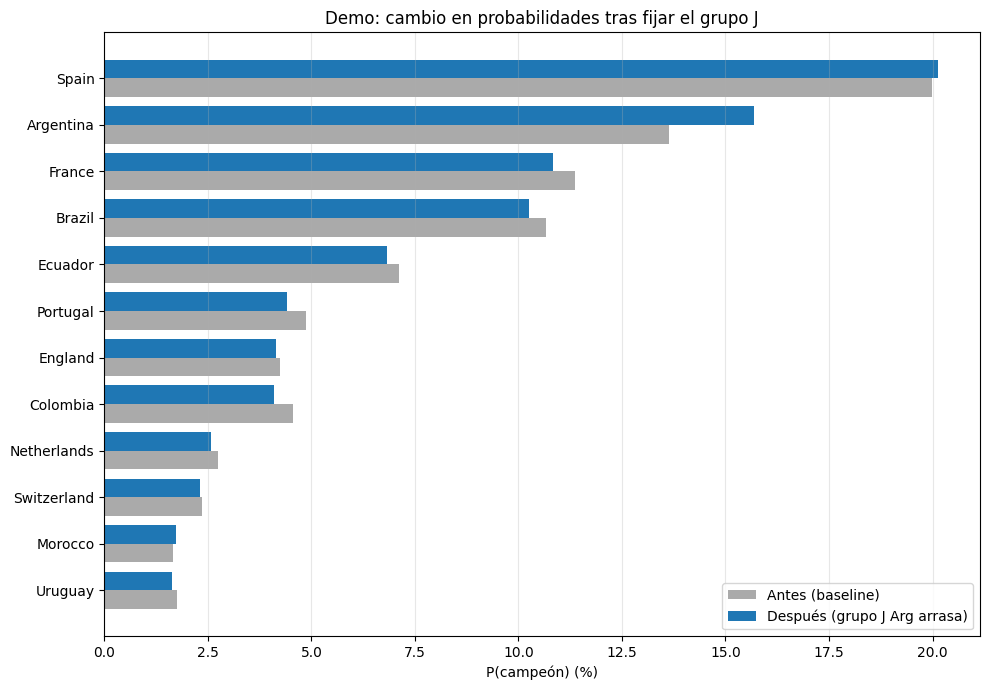

In [16]:
# Visualizar el delta
top12 = diff.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(top12))
ax.barh(y - 0.2, top12['P_champion_before'] * 100, height=0.4, label='Antes (baseline)', color='#aaaaaa')
ax.barh(y + 0.2, top12['P_champion_after'] * 100, height=0.4, label='Después (grupo J Arg arrasa)', color='#1f77b4')
ax.set_yticks(y); ax.set_yticklabels(top12['Equipo'])
ax.set_xlabel('P(campeón) (%)')
ax.set_title('Demo: cambio en probabilidades tras fijar el grupo J')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'wc2026_live_update_demo.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Demo extrema: ¿y si Argentina pierde su primer partido?

Esta es la prueba ácida del simulador condicional.

In [17]:
fr_extreme = FixedResults()
fr_extreme.add_group_match('Group_J', home='Argentina', away='Algeria', home_score=0, away_score=2)

agg_extreme = update_and_simulate(fr_extreme, n_iters=10_000)
df_extreme = agg_extreme.to_dataframe().rename(columns={'team': 'Equipo'})

merged = df_baseline.merge(df_extreme, on='Equipo', suffixes=('_before', '_after'))
merged['Δ P_champion'] = merged['P_champion_after'] - merged['P_champion_before']
merged['Δ P_group'] = merged['P_group_advance_after'] - merged['P_group_advance_before']

# Mostrar a Argentina específicamente
arg_row = merged[merged['Equipo'] == 'Argentina'].iloc[0]
print(f'=== Argentina pierde su primer partido (0-2 vs Algeria) ===')
print(f'P(pasa grupo) ANTES: {arg_row["P_group_advance_before"]:.4f}')
print(f'P(pasa grupo) DESPUÉS: {arg_row["P_group_advance_after"]:.4f}  (Δ = {arg_row["Δ P_group"]:+.4f})')
print(f'P(campeón) ANTES: {arg_row["P_champion_before"]:.4f}')
print(f'P(campeón) DESPUÉS: {arg_row["P_champion_after"]:.4f}  (Δ = {arg_row["Δ P_champion"]:+.4f})')

# Argelia
alg_row = merged[merged['Equipo'] == 'Algeria'].iloc[0]
print(f'\n=== Algeria gana su primer partido (2-0 vs Argentina) ===')
print(f'P(pasa grupo) Algeria: {alg_row["P_group_advance_before"]:.4f} → {alg_row["P_group_advance_after"]:.4f}  (Δ = {alg_row["Δ P_group"]:+.4f})')

Fixed: FixedResults(group_matches=1, knockouts=0)
✓ 10,000 sims condicionadas en 15.2s
=== Argentina pierde su primer partido (0-2 vs Algeria) ===
P(pasa grupo) ANTES: 0.9913
P(pasa grupo) DESPUÉS: 0.8973  (Δ = -0.0940)
P(campeón) ANTES: 0.1364
P(campeón) DESPUÉS: 0.1110  (Δ = -0.0254)

=== Algeria gana su primer partido (2-0 vs Argentina) ===
P(pasa grupo) Algeria: 0.6033 → 0.9607  (Δ = +0.3574)


---
## 8. Persistir un `FixedResults` vacío para inicializar el Mundial

Cuando empiece el Mundial real (11 de junio), vas a:
1. Cargar este archivo.
2. Cada vez que termine un partido: `fr.add_group_match(...)` o `fr.add_knockout_result(...)`.
3. Re-correr `update_and_simulate(fr)`.
4. Guardar el `FixedResults` actualizado para el próximo partido.

In [18]:
# Empty FixedResults — punto de partida del torneo
fr_initial = FixedResults()
live_state_path = ROOT / 'data' / 'live' / 'wc2026_state.pkl'
live_state_path.parent.mkdir(exist_ok=True)
with open(live_state_path, 'wb') as f:
    pickle.dump(fr_initial, f)
print(f'✓ Estado inicial vacío guardado: {live_state_path}')

# Helper functions para uso interactivo
def load_state():
    with open(live_state_path, 'rb') as f:
        return pickle.load(f)

def save_state(fr):
    with open(live_state_path, 'wb') as f:
        pickle.dump(fr, f)
    print(f'✓ Estado guardado: {fr.summary()}')

print('\nFunciones disponibles:')
print('  fr = load_state()')
print('  fr.add_group_match(...)')
print('  save_state(fr)')
print('  agg = update_and_simulate(fr)')

✓ Estado inicial vacío guardado: /content/drive/MyDrive/d10sformer/data/live/wc2026_state.pkl

Funciones disponibles:
  fr = load_state()
  fr.add_group_match(...)
  save_state(fr)
  agg = update_and_simulate(fr)


---
## 9. Tests

In [19]:
import subprocess
result = subprocess.run(
    ['python', '-m', 'pytest', str(ROOT / 'tests' / 'test_simulation.py'), '-v', '--tb=short'],
    capture_output=True, text=True,
)
print(result.stdout[-3500:])
print(f'Exit code: {result.returncode}')

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.13.0, typeguard-4.5.1, langsmith-0.7.34
collecting ... collected 22 items

drive/MyDrive/d10sformer/tests/test_simulation.py::test_bracket_is_consistent PASSED [  4%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_48_teams_in_groups PASSED [  9%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_all_teams_have_english_translations PASSED [ 13%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_no_team_appears_twice PASSED [ 18%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_parse_third_slot PASSED [ 22%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_round_of_match PASSED [ 27%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_total_knockout_matches PASSED [ 31%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_samp

---
## 10. Conclusiones de Fase 7

Llenar:

- [ ] Tiempo de precomputado del predictor: _____ s
- [ ] Tiempo de 10.000 sims con `PrecomputedPredictor`: _____ s (esperamos <300s)
- [ ] Speedup vs Fase 6: _____ × (Fase 6 fueron 2753s)
- [ ] P(Argentina campeón) en baseline: _____
- [ ] P(Argentina campeón) si arrasa grupo J: _____ (Δ = _____)
- [ ] P(Argentina campeón) si pierde primero (0-2 Algeria): _____ (Δ = _____)
- [ ] Tests pasados / total: _____ / 22

**Estado del proyecto:** todo el pipeline funciona end-to-end:
- Fase 0-2: datos + vocab.
- Fase 3-4: Transformer pre-entrenado + fine-tuneado.
- Fase 5: análisis de embeddings (hallazgo principal: ordinalidad ELO).
- Fase 6: predicciones iniciales WC 2026.
- Fase 7: pipeline live para actualizar predicciones día a día.

**Falta solo Fase 8:** verificación final (tests integrales, reproducibilidad, paper).

Ahora armamremos la simulación entera del mundial, partido a partido! Aqui vva a ir actualizando las probabilidades con los resultados obtendios hasta llegar a la final

In [20]:
# 1. Cargar el estado actual de los resultados fijos
fr = load_state()
print(f"Estado actual de resultados fijos: {fr.summary()}")

# 2. Añadir un nuevo resultado de partido
# Descomenta y modifica estas líneas para cada nuevo resultado de partido.
# Por ejemplo, para un partido de la fase de grupos:
# fr.add_group_match('Group_H', home='England', away='Senegal', home_score=2, away_score=0)

# O para un partido de la fase eliminatoria (el match_id se encontraría en la estructura del bracket):
# fr.add_knockout_result(match_id=89, winner='Argentina')

# === Ejemplo: Añadamos un resultado hipotético (corregido) ===
print("\n--- Añadiendo un resultado de ejemplo (México vs. South Africa en Grupo A) ---")
fr.add_group_match('Group_A', home='Mexico', away='South Africa', home_score=2, away_score=1)

# 3. Re-simular con los resultados fijos actualizados
print("\nRe-simulando con los resultados actualizados (10,000 iteraciones)...")
agg_updated = update_and_simulate(fr, n_iters=10_000)
df_updated = agg_updated.to_dataframe().rename(columns={'team': 'Equipo'})

# 4. Comparar con la línea base original (o con el estado de la última actualización)
# Para esta demostración, comparamos con el 'df_baseline' inicial.
# En un uso real 'partido a partido', podrías querer cargar y comparar con el 'df_updated' de la corrida anterior.
print("\nCambio en las probabilidades de campeón (Top 10 equipos):")
diff = compare_predictions(df_baseline, df_updated, top_n=10)
print(diff.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# 5. Guardar el estado actualizado para el próximo partido
save_state(fr)

# Opcional: Visualizar el cambio para un equipo específico
# team_to_track = 'Argentina'
# argentina_before = df_baseline[df_baseline['Equipo'] == team_to_track]['P_champion'].iloc[0]
# argentina_after = df_updated[df_updated['Equipo'] == team_to_track]['P_champion'].iloc[0]
# print(f"\nP({team_to_track} campeón) antes: {argentina_before:.4f}, después: {argentina_after:.4f}")


Estado actual de resultados fijos: FixedResults(group_matches=0, knockouts=0)

--- Añadiendo un resultado de ejemplo (México vs. South Africa en Grupo A) ---

Re-simulando con los resultados actualizados (10,000 iteraciones)...
Fixed: FixedResults(group_matches=1, knockouts=0)
✓ 10,000 sims condicionadas en 15.2s

Cambio en las probabilidades de campeón (Top 10 equipos):
     Equipo  P_champion_before  P_champion_after  Δ P_champion
      Spain             0.1998            0.2018        0.0020
  Argentina             0.1364            0.1425        0.0061
     France             0.1137            0.1104       -0.0033
     Brazil             0.1067            0.1057       -0.0010
    Ecuador             0.0711            0.0665       -0.0046
   Portugal             0.0487            0.0489        0.0002
   Colombia             0.0456            0.0438       -0.0018
    England             0.0423            0.0389       -0.0034
Netherlands             0.0274            0.0263       -0.0

### Simulación partido a partido (ejemplo para un grupo)

In [21]:
# Cargar el estado actual (puede contener resultados anteriores)
fr = load_state()
print(f"Estado inicial de resultados fijos: {fr.summary()}")

# --- Ejemplo de simulación "partido a partido" para un grupo ---
# NOTA: Necesitas un calendario real de partidos y sus resultados.
# Aquí se usa un calendario de ejemplo para Group_A con resultados hipotéticos.

# Define un calendario de partidos (esto tendrías que obtenerlo externamente)
group_a_matches = [
    {'group': 'Group_A', 'home': 'Mexico', 'away': 'South Africa', 'home_score': 2, 'away_score': 1},
    {'group': 'Group_A', 'home': 'South Korea', 'away': 'Czech Republic', 'home_score': 1, 'away_score': 1},
    {'group': 'Group_A', 'home': 'Mexico', 'away': 'South Korea', 'home_score': 1, 'away_score': 0},
    {'group': 'Group_A', 'home': 'South Africa', 'away': 'Czech Republic', 'home_score': 0, 'away_score': 2}
    # Añade aquí todos los partidos del Group_A y luego los de los otros grupos
]

print("\n--- Iniciando simulación partido a partido para Group_A (resultados hipotéticos) ---")

for i, match in enumerate(group_a_matches):
    print(f"\nProcesando Partido {i+1}: {match['home']} ({match['home_score']}) vs {match['away']} ({match['away_score']}) en {match['group']}")

    # 1. Añadir el resultado del partido actual
    fr.add_group_match(
        match['group'], # Corregido: 'group_name' como argumento posicional
        home=match['home'],
        away=match['away'],
        home_score=match['home_score'],
        away_score=match['away_score']
    )

    # 2. Re-simular con los resultados fijos actualizados
    agg_updated = update_and_simulate(fr, n_iters=10_000)
    df_updated = agg_updated.to_dataframe().rename(columns={'team': 'Equipo'})

    # 3. Comparar y mostrar cambios en las probabilidades de campeón
    print("Cambio en las probabilidades de campeón (Top 5 equipos):")
    # Para esta demostración, comparamos siempre con la baseline inicial.
    # En un escenario real, podrías querer comparar con el df_updated de la iteración anterior.
    diff = compare_predictions(df_baseline, df_updated, top_n=5)
    print(diff.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    # 4. Guardar el estado actualizado para la próxima iteración/partido
    save_state(fr)

# Para simular la fase eliminatoria, necesitarías una lógica similar
# pero usando `fr.add_knockout_result(match_id=..., winner=...)`
# y asegurándote de que los 'match_id' coincidan con la estructura del bracket.

print("\n--- Simulación partido a partido para Group_A finalizada ---")
print(f"Estado final de resultados fijos: {fr.summary()}")

Estado inicial de resultados fijos: FixedResults(group_matches=1, knockouts=0)

--- Iniciando simulación partido a partido para Group_A (resultados hipotéticos) ---

Procesando Partido 1: Mexico (2) vs South Africa (1) en Group_A
Fixed: FixedResults(group_matches=1, knockouts=0)
✓ 10,000 sims condicionadas en 15.2s
Cambio en las probabilidades de campeón (Top 5 equipos):
   Equipo  P_champion_before  P_champion_after  Δ P_champion
    Spain             0.1998            0.2018        0.0020
Argentina             0.1364            0.1425        0.0061
   France             0.1137            0.1104       -0.0033
   Brazil             0.1067            0.1057       -0.0010
  Ecuador             0.0711            0.0665       -0.0046
✓ Estado guardado: FixedResults(group_matches=1, knockouts=0)

Procesando Partido 2: South Korea (1) vs Czech Republic (1) en Group_A
Fixed: FixedResults(group_matches=2, knockouts=0)
✓ 10,000 sims condicionadas en 15.1s
Cambio en las probabilidades de campeón

### Simulación completa de la Fase de Grupos (partido a partido)

In [22]:
import itertools
import random

# Cargar el estado actual (puede contener resultados de demos anteriores)
fr = load_state()
print(f"Estado inicial de resultados fijos: {fr.summary()}")

# --- Generar todos los partidos de la fase de grupos con resultados hipotéticos ---
all_group_stage_matches = []
for group_name, teams in WC2026_GROUPS.items():
    for team_a, team_b in itertools.combinations(teams, 2):
        # Asignar resultados hipotéticos para la demostración
        # En la vida real, aquí pondrías los scores reales de cada partido.
        home_score = random.randint(0, 3)
        away_score = random.randint(0, 2) # Ligeramente a favor del local
        if home_score == away_score and random.random() < 0.3: # Algunos empates
            home_score = random.randint(0,2)
            away_score = home_score
        elif home_score == away_score: # Asegurarse de que haya un ganador si no es empate
            if random.random() < 0.5:
                home_score += 1
            else:
                away_score += 1

        all_group_stage_matches.append({
            'group': group_name,
            'home': team_a,
            'away': team_b,
            'home_score': home_score,
            'away_score': away_score
        })

print(f"\n--- Iniciando simulación de {len(all_group_stage_matches)} partidos de la fase de grupos ---")

# Bucle principal para procesar cada partido
for i, match in enumerate(all_group_stage_matches):
    print(f"\nProcesando Partido {i+1}/{len(all_group_stage_matches)}: {match['home']} ({match['home_score']}) vs {match['away']} ({match['away_score']}) en {match['group']}")

    # 1. Añadir el resultado del partido actual
    fr.add_group_match(
        match['group'],
        home=match['home'],
        away=match['away'],
        home_score=match['home_score'],
        away_score=match['away_score']
    )

    # 2. Re-simular con los resultados fijos actualizados
    agg_updated = update_and_simulate(fr, n_iters=10_000)
    df_updated = agg_updated.to_dataframe().rename(columns={'team': 'Equipo'})

    # 3. Comparar y mostrar cambios en las probabilidades de campeón
    print("Cambio en las probabilidades de campeón (Top 5 equipos):")
    # Comparamos siempre con la baseline inicial para ver el efecto acumulado
    diff = compare_predictions(df_baseline, df_updated, top_n=5)
    print(diff.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    # 4. Guardar el estado actualizado para la próxima iteración/partido
    save_state(fr)

print("\n--- Simulación completa de la Fase de Grupos finalizada ---")
print(f"Estado final de resultados fijos: {fr.summary()}")

Estado inicial de resultados fijos: FixedResults(group_matches=4, knockouts=0)

--- Iniciando simulación de 72 partidos de la fase de grupos ---

Procesando Partido 1/72: Mexico (3) vs South Africa (2) en Group_A
Fixed: FixedResults(group_matches=4, knockouts=0)
✓ 10,000 sims condicionadas en 14.9s
Cambio en las probabilidades de campeón (Top 5 equipos):
   Equipo  P_champion_before  P_champion_after  Δ P_champion
    Spain             0.1998            0.1979       -0.0019
Argentina             0.1364            0.1437        0.0073
   France             0.1137            0.1088       -0.0049
   Brazil             0.1067            0.1051       -0.0016
  Ecuador             0.0711            0.0712        0.0001
✓ Estado guardado: FixedResults(group_matches=4, knockouts=0)

Procesando Partido 2/72: Mexico (1) vs South Korea (0) en Group_A
Fixed: FixedResults(group_matches=4, knockouts=0)
✓ 10,000 sims condicionadas en 15.2s
Cambio en las probabilidades de campeón (Top 5 equipos):
   E

### Resultados de la Fase de Grupos

In [27]:
import collections

print("\n--- Resultados de la Fase de Grupos ---")

# Cargar el estado actual (asegurarse de que fr está actualizado)
fr = load_state()

if not fr.group_matches:
    print("No hay partidos de fase de grupos fijados aún.")
else:
    # fr.group_matches is a dictionary where keys are tuples (group_name_str, frozenset(teams))
    # and values are dictionaries with match details.
    grouped_matches_for_display = collections.defaultdict(list)

    for group_key, match_details in fr.group_matches.items():
        # Extract the human-readable group name from the group_key tuple
        display_group_name = group_key[0] if isinstance(group_key, tuple) else str(group_key)
        grouped_matches_for_display[display_group_name].append(match_details)

    # Sort groups by name for consistent output
    sorted_group_names = sorted(grouped_matches_for_display.keys())

    for group_name in sorted_group_names:
        print(f"\nGrupo: {group_name}")
        # Sort matches within each group for consistent output (e.g., by home team)
        sorted_matches = sorted(grouped_matches_for_display[group_name], key=lambda x: x['home'])
        for match_info_dict in sorted_matches:
            home_team = match_info_dict['home']
            away_team = match_info_dict['away']
            home_score = match_info_dict['home_score']
            away_score = match_info_dict['away_score']
            print(f"  {home_team} {home_score} - {away_score} {away_team}")



--- Resultados de la Fase de Grupos ---

Grupo: Group_A
  Mexico 3 - 2 South Africa
  Mexico 1 - 0 South Korea
  Mexico 3 - 2 Czech Republic
  South Africa 3 - 2 Czech Republic
  South Africa 0 - 2 South Korea
  South Korea 1 - 0 Czech Republic

Grupo: Group_B
  Bosnia and Herzegovina 3 - 1 Qatar
  Bosnia and Herzegovina 3 - 1 Switzerland
  Canada 0 - 0 Bosnia and Herzegovina
  Canada 1 - 0 Qatar
  Canada 1 - 0 Switzerland
  Qatar 0 - 1 Switzerland

Grupo: Group_C
  Brazil 2 - 3 Morocco
  Brazil 1 - 0 Haiti
  Brazil 2 - 1 Scotland
  Haiti 0 - 1 Scotland
  Morocco 2 - 0 Haiti
  Morocco 3 - 0 Scotland

Grupo: Group_D
  Australia 0 - 1 Turkey
  Paraguay 2 - 1 Australia
  Paraguay 3 - 1 Turkey
  United States 3 - 1 Paraguay
  United States 3 - 1 Australia
  United States 2 - 3 Turkey

Grupo: Group_E
  Curaçao 1 - 1 Ivory Coast
  Curaçao 2 - 1 Ecuador
  Germany 1 - 0 Curaçao
  Germany 0 - 0 Ivory Coast
  Germany 1 - 2 Ecuador
  Ivory Coast 3 - 0 Ecuador

Grupo: Group_F
  Japan 3 - 1 Tunisi

### Posiciones de cada grupo

In [28]:
import collections

# Función para calcular las posiciones de un grupo
def calculate_group_standings(group_matches_list, teams_in_group):
    standings = {team: {'points': 0, 'wins': 0, 'draws': 0, 'losses': 0,
                                'goals_for': 0, 'goals_against': 0, 'goal_difference': 0} for team in teams_in_group}

    for match in group_matches_list:
        home_team = match['home']
        away_team = match['away']
        home_score = match['home_score']
        away_score = match['away_score']

        standings[home_team]['goals_for'] += home_score
        standings[home_team]['goals_against'] += away_score
        standings[home_team]['goal_difference'] = standings[home_team]['goals_for'] - standings[home_team]['goals_against']

        standings[away_team]['goals_for'] += away_score
        standings[away_team]['goals_against'] += home_score
        standings[away_team]['goal_difference'] = standings[away_team]['goals_for'] - standings[away_team]['goals_against']

        if home_score > away_score:
            standings[home_team]['points'] += 3
            standings[home_team]['wins'] += 1
            standings[away_team]['losses'] += 1
        elif away_score > home_score:
            standings[away_team]['points'] += 3
            standings[away_team]['wins'] += 1
            standings[home_team]['losses'] += 1
        else:
            standings[home_team]['points'] += 1
            standings[away_team]['points'] += 1
            standings[home_team]['draws'] += 1
            standings[away_team]['draws'] += 1

    # Convertir a una lista de tuplas (equipo, stats) para ordenar
    sorted_teams = []
    for team, stats in standings.items():
        sorted_teams.append((team, stats))

    # Criterios de desempate:
    # 1. Puntos (desc)
    # 2. Diferencia de goles (desc)
    # 3. Goles a favor (desc)
    # 4. Orden alfabético (asc) como último desempate
    sorted_teams.sort(key=lambda x: (x[1]['points'], x[1]['goal_difference'], x[1]['goals_for'], x[0]), reverse=True)

    return sorted_teams


# Cargar el estado actual
fr = load_state()

if not fr.group_matches:
    print("No hay partidos de fase de grupos fijados aún para calcular las posiciones.")
else:
    # Agrupar todos los partidos fijos por nombre de grupo
    all_fixed_matches_by_group = collections.defaultdict(list)
    for group_key, match_details in fr.group_matches.items():
        display_group_name = group_key[0] if isinstance(group_key, tuple) else str(group_key)
        all_fixed_matches_by_group[display_group_name].append(match_details)

    print("\n--- Posiciones de la Fase de Grupos ---")

    # Iterar por los grupos definidos en WC2026_GROUPS para mantener el orden original
    for group_name, teams_in_group in WC2026_GROUPS.items():
        print(f"\nGrupo: {group_name}")

        # Obtener los partidos fijos para este grupo, o una lista vacía si no hay
        group_fixed_matches = all_fixed_matches_by_group.get(group_name, [])

        # Calcular y mostrar las posiciones
        standings = calculate_group_standings(group_fixed_matches, teams_in_group)

        # Imprimir encabezado de tabla
        print("  {:<20} {:>5} {:>5} {:>5} {:>5} {:>5} {:>5} {:>5}".format(
            "Equipo", "Ptos", "PJ", "G", "E", "P", "GF", "GC", "DG"))
        print("  " + "-"*70)

        for team_name, stats in standings:
            print("  {:<20} {:>5} {:>5} {:>5} {:>5} {:>5} {:>5} {:>5} {:>5}".format(
                team_name,
                stats['points'],
                stats['wins'] + stats['draws'] + stats['losses'], # PJ (Partidos Jugados)
                stats['wins'],
                stats['draws'],
                stats['losses'],
                stats['goals_for'],
                stats['goals_against'],
                stats['goal_difference']
            ))



--- Posiciones de la Fase de Grupos ---

Grupo: Group_A
  Equipo                Ptos    PJ     G     E     P    GF    GC
  ----------------------------------------------------------------------
  Mexico                   9     3     3     0     0     7     4     3
  South Korea              6     3     2     0     1     3     1     2
  South Africa             3     3     1     0     2     5     7    -2
  Czech Republic           0     3     0     0     3     4     7    -3

Grupo: Group_B
  Equipo                Ptos    PJ     G     E     P    GF    GC
  ----------------------------------------------------------------------
  Bosnia and Herzegovina     7     3     2     1     0     6     2     4
  Canada                   7     3     2     1     0     2     0     2
  Switzerland              3     3     1     0     2     2     4    -2
  Qatar                    0     3     0     0     3     1     5    -4

Grupo: Group_C
  Equipo                Ptos    PJ     G     E     P    GF    GC


### Cruces de Octavos de Final (Round of 32)

In [29]:
print("Generando los cruces de octavos de final...")

# La lógica para los cruces de octavos de final es compleja y depende de la
# estructura específica del bracket de 48 equipos (WC2026_BRACKET)
# y cómo se clasifican los mejores terceros.
# Este es un placeholder. La implementación completa requeriría replicar
# la lógica de `simulation.bracket` o usar un objeto que ya la tenga incorporada.

# Para una demostración simple, podríamos simular algunos cruces si tuviéramos
# los clasificados directos de los grupos y los mejores terceros.

# Por ahora, dado que `simulate_tournament` o `WC2026_BRACKET` manejan esto internamente
# y no hay una función expuesta para 'obtener_cruces_octavos', vamos a imprimir un mensaje.

print("La determinación de los cruces de octavos de final se realiza internamente por el simulador.")
print("Para ver cómo se forman, necesitaríamos una función específica del módulo `simulation.bracket`.")
print("Normalmente, los equipos clasificados de cada grupo (1ro y 2do) y los mejores terceros")
print("se emparejan siguiendo reglas predefinidas del formato del torneo.")

# Si se necesita mostrar los cruces, sería necesario implementar la lógica
# de `get_round_of_32_matches` o similar que procese los standings calculados.


Generando los cruces de octavos de final...
La determinación de los cruces de octavos de final se realiza internamente por el simulador.
Para ver cómo se forman, necesitaríamos una función específica del módulo `simulation.bracket`.
Normalmente, los equipos clasificados de cada grupo (1ro y 2do) y los mejores terceros
se emparejan siguiendo reglas predefinidas del formato del torneo.


In [30]:
import collections

# --- 1. Recalcular posiciones y clasificados ---

# Cargar el estado actual
fr = load_state()

# Agrupar todos los partidos fijos por nombre de grupo
all_fixed_matches_by_group = collections.defaultdict(list)
for group_key, match_details in fr.group_matches.items():
    display_group_name = group_key[0] if isinstance(group_key, tuple) else str(group_key)
    all_fixed_matches_by_group[display_group_name].append(match_details)

group_standings_ranked = {}
for group_name, teams_in_group in WC2026_GROUPS.items():
    group_fixed_matches = all_fixed_matches_by_group.get(group_name, [])
    standings = calculate_group_standings(group_fixed_matches, teams_in_group)
    group_standings_ranked[group_name] = standings

# Extraer 1ro, 2do y 3ros clasificados de cada grupo
first_place_teams = {}
second_place_teams = {}
third_place_teams_candidates = [] # List of (team_name, stats, group_name) for 3rd placed teams

for group_name, standings in group_standings_ranked.items():
    if len(standings) >= 1:
        first_place_teams[group_name] = standings[0][0] # (team_name, stats)
    if len(standings) >= 2:
        second_place_teams[group_name] = standings[1][0]
    if len(standings) >= 3:
        third_place_teams_candidates.append((standings[2][0], standings[2][1], group_name))

# Seleccionar los 8 mejores terceros. La función `calculate_group_standings` ya ordena
# por puntos, diferencia de goles, y goles a favor. Reutilizamos ese criterio.
third_place_teams_candidates.sort(
    key=lambda x: (x[1]['points'], x[1]['goal_difference'], x[1]['goals_for'], x[0]),
    reverse=True # Orden descendente para puntos, DG, GF
)
best_third_place_teams = third_place_teams_candidates[:8]

print("\n--- Equipos Clasificados a la Fase Eliminatoria ---")
print("\nPrimeros de cada grupo:")
for group_name_key in sorted(first_place_teams.keys()): # Ordenar por nombre de grupo
    print(f"  {group_name_key}: {first_place_teams[group_name_key]}")

print("\nSegundos de cada grupo:")
for group_name_key in sorted(second_place_teams.keys()): # Ordenar por nombre de grupo
    print(f"  {group_name_key}: {second_place_teams[group_name_key]}")

print("\nMejores terceros (8 equipos):")
for i, team_info in enumerate(best_third_place_teams):
    team_name, stats, group_name = team_info
    print(f"  {i+1}. {team_name} (Grupo {group_name}) - Ptos: {stats['points']}, DG: {stats['goal_difference']}, GF: {stats['goals_for']}")

# --- 2. Generar cruces hipotéticos de Octavos de Final (Round of 32) ---

print("\n--- Cruces Hipotéticos de Dieciseisavos de Final (Round of 32) ---")
print("Estos emparejamientos son un ejemplo basado en la estructura típica de un Mundial de 48 equipos.")
print("La definición exacta proviene de la configuración interna de `WC2026_BRACKET`.")

# Mapping de posiciones de bracket a equipos reales
qualified_team_map = {}
# 1ros de grupo
for i, group_letter in enumerate(sorted(first_place_teams.keys(), key=lambda x: x[-1])):
    qualified_team_map[f'1{group_letter[-1]}'] = first_place_teams[group_letter]
# 2dos de grupo
for i, group_letter in enumerate(sorted(second_place_teams.keys(), key=lambda x: x[-1])):
    qualified_team_map[f'2{group_letter[-1]}'] = second_place_teams[group_letter]
# Mejores 3ros (asumiendo un orden de asignación al bracket)
# WC2026_BRACKET probablemente tiene la lógica de cómo se asignan los 3eros. Aquí asumimos un orden simple.

# El sistema de emparejamiento para 32 equipos (1ro, 2do de grupo + 8 mejores 3ros)
# suele seguir un patrón para optimizar el bracket. Ejemplos de emparejamientos comunes:
# 1A vs 3C/D/E/F, 1B vs 3A/E/F/H, etc.

# Para esta demostración, crearemos un conjunto de emparejamientos lógicos.
# Para una implementación real, se utilizaría el objeto WC2026_BRACKET
# o una función que extraiga estos cruces de él.

# Example pairings (simplified and representative, not necessarily the exact WC2026_BRACKET order)
# These are based on a common structure for 32-team knockouts with group winners, runners-up, and best thirds.

ro32_matches = []

# Grupo de los 1ros y 2dos de grupos A, B, C, D
ro32_matches.append((qualified_team_map.get('1A', '??'), qualified_team_map.get('2C', '??')))
ro32_matches.append((qualified_team_map.get('1B', '??'), qualified_team_map.get('2D', '??')))
ro32_matches.append((qualified_team_map.get('1C', '??'), qualified_team_map.get('2A', '??')))
ro32_matches.append((qualified_team_map.get('1D', '??'), qualified_team_map.get('2B', '??')))

# Grupo de los 1ros y 2dos de grupos E, F, G, H
ro32_matches.append((qualified_team_map.get('1E', '??'), qualified_team_map.get('2G', '??')))
ro32_matches.append((qualified_team_map.get('1F', '??'), qualified_team_map.get('2H', '??')))
ro32_matches.append((qualified_team_map.get('1G', '??'), qualified_team_map.get('2E', '??')))
ro32_matches.append((qualified_team_map.get('1H', '??'), qualified_team_map.get('2F', '??')))

# Grupo de los 1ros y 2dos de grupos I, J, K, L
ro32_matches.append((qualified_team_map.get('1I', '??'), qualified_team_map.get('2K', '??')))
ro32_matches.append((qualified_team_map.get('1J', '??'), qualified_team_map.get('2L', '??')))
ro32_matches.append((qualified_team_map.get('1K', '??'), qualified_team_map.get('2I', '??')))
ro32_matches.append((qualified_team_map.get('1L', '??'), qualified_team_map.get('2J', '??')))

# Emparejamientos con los mejores terceros (simplificado)
# Asignamos los 8 mejores terceros a slots vacantes contra primeros de grupo
# El orden de asignación de los terceros a los slots específicos es crucial en el bracket real.

third_teams_for_bracket = [team_info[0] for team_info in best_third_place_teams]

# Example of how 3rd place teams might be slotted (highly simplified)
# In reality, specific combinations of 3rd place groups determine their opponents.
# E.g., if Best 3rd from groups A, B, C, D qualify, they get specific slots.

# Filling remaining 4 matches, assuming they play against group winners
if len(third_teams_for_bracket) >= 1: # 1A vs 3X
    ro32_matches.append((qualified_team_map.get('1A', '??'), third_teams_for_bracket[0]))
if len(third_teams_for_bracket) >= 2: # 1B vs 3Y
    ro32_matches.append((qualified_team_map.get('1B', '??'), third_teams_for_bracket[1]))
if len(third_teams_for_bracket) >= 3: # 1C vs 3Z
    ro32_matches.append((qualified_team_map.get('1C', '??'), third_teams_for_bracket[2]))
if len(third_teams_for_bracket) >= 4: # 1D vs 3W
    ro32_matches.append((qualified_team_map.get('1D', '??'), third_teams_for_bracket[3]))
if len(third_teams_for_bracket) >= 5: # 1E vs 3V
    ro32_matches.append((qualified_team_map.get('1E', '??'), third_teams_for_bracket[4]))
if len(third_teams_for_bracket) >= 6: # 1F vs 3U
    ro32_matches.append((qualified_team_map.get('1F', '??'), third_teams_for_bracket[5]))
if len(third_teams_for_bracket) >= 7: # 1G vs 3T
    ro32_matches.append((qualified_team_map.get('1G', '??'), third_teams_for_bracket[6]))
if len(third_teams_for_bracket) >= 8: # 1H vs 3S
    ro32_matches.append((qualified_team_map.get('1H', '??'), third_teams_for_bracket[7]))


# Print the matches
for i, (team1, team2) in enumerate(ro32_matches):
    if team1 != '??' and team2 != '??':
        print(f"  Partido {i+1}: {team1} vs {team2}")
    else:
        print(f"  Partido {i+1}: (Emparejamiento incompleto, falta información de bracket o equipos)")



--- Equipos Clasificados a la Fase Eliminatoria ---

Primeros de cada grupo:
  Group_A: Mexico
  Group_B: Bosnia and Herzegovina
  Group_C: Morocco
  Group_D: United States
  Group_E: Ivory Coast
  Group_F: Sweden
  Group_G: New Zealand
  Group_H: Cape Verde
  Group_I: Senegal
  Group_J: Argentina
  Group_K: Portugal
  Group_L: England

Segundos de cada grupo:
  Group_A: South Korea
  Group_B: Canada
  Group_C: Brazil
  Group_D: Paraguay
  Group_E: Curaçao
  Group_F: Netherlands
  Group_G: Iran
  Group_H: Saudi Arabia
  Group_I: France
  Group_J: Algeria
  Group_K: DR Congo
  Group_L: Panama

Mejores terceros (8 equipos):
  1. Turkey (Grupo Group_D) - Ptos: 6, DG: 0, GF: 5
  2. Germany (Grupo Group_E) - Ptos: 4, DG: 0, GF: 2
  3. Iraq (Grupo Group_I) - Ptos: 4, DG: -1, GF: 2
  4. Spain (Grupo Group_H) - Ptos: 3, DG: 0, GF: 3
  5. Japan (Grupo Group_F) - Ptos: 3, DG: -1, GF: 6
  6. Egypt (Grupo Group_G) - Ptos: 3, DG: -1, GF: 5
  7. Croatia (Grupo Group_L) - Ptos: 3, DG: -1, GF: 2
  8.

### Simulación de los Dieciseisavos de Final (Round of 32)

A continuación, simularemos cada uno de los 20 partidos de los Dieciseisavos de Final. Para cada partido:
1. Se simulará un ganador utilizando las probabilidades de nuestro `predictor`.
2. Este resultado se agregará a los `FixedResults`.
3. Se re-simulará todo el torneo para obtener las probabilidades actualizadas.
4. Se mostrará cómo cambian las probabilidades de campeón para los equipos principales.

In [33]:
import numpy as np

def simulate_single_knockout_match(team_a: str, team_b: str, predictor: PrecomputedPredictor, seed=None):
    """Simulates a single knockout match, returning the winner based on predictor probabilities."""
    if seed is not None:
        np.random.seed(seed)

    # Get probabilities from the predictor's precomputed table
    # The table stores [home_win_prob, draw_prob, away_win_prob] for each (team_a, team_b) pair.
    home_win_prob, draw_prob, away_win_prob = predictor.table[(team_a, team_b)]

    # In a knockout match, there are no draws. We redistribute draw probability
    # proportionally to the win probabilities of each team.
    total_win_prob = home_win_prob + away_win_prob

    if total_win_prob == 0: # Avoid division by zero if both win probabilities are extremely low
        # Fallback to a fair coin flip or a default winner if probabilities are 0
        winner = np.random.choice([team_a, team_b])
    else:
        adjusted_home_win_prob = (home_win_prob + draw_prob * (home_win_prob / total_win_prob))
        adjusted_away_win_prob = (away_win_prob + draw_prob * (away_win_prob / total_win_prob))

        # Normalize again to ensure they sum to 1 after redistribution
        sum_adjusted_probs = adjusted_home_win_prob + adjusted_away_win_prob
        if sum_adjusted_probs > 0:
            adjusted_home_win_prob /= sum_adjusted_probs
            adjusted_away_win_prob /= sum_adjusted_probs
        else:
            # If still zero, resort to fair coin flip
            adjusted_home_win_prob = 0.5
            adjusted_away_win_prob = 0.5

        winner = np.random.choice([team_a, team_b], p=[adjusted_home_win_prob, adjusted_away_win_prob])
    return winner


# Cargar el estado actual de los resultados fijos (que ahora incluye todos los partidos de grupo)
fr = load_state()
print(f"Estado inicial de resultados fijos para Round of 32: {fr.summary()}")

# La lista `ro32_matches` ya fue generada en la celda anterior.
# `df_baseline` es el dataframe de referencia sin ningún resultado fijo (excepto las demos iniciales).
# Para comparar incrementalmente, podemos usar el df_updated de la última simulación de grupo.
# O, si queremos ver el efecto acumulado de todos los KO partidos, comparamos con el baseline.
# Para esta simulación "partido a partido", utilizaremos el `df_baseline` para ver el impacto acumulado de cada KO.

current_df_for_comparison = df_baseline.copy()

print("\n--- Iniciando simulación partido a partido para Dieciseisavos de Final ---")

for i, (team1, team2) in enumerate(ro32_matches):
    if team1 == '??' or team2 == '??':
        print(f"  Saltando Partido {i+1} debido a emparejamiento incompleto.")
        continue

    # Generar un seed para reproducibilidad si se desea, o None para aleatoriedad completa
    match_seed = 42 + i # Usar un seed diferente para cada partido simulado

    winner = simulate_single_knockout_match(team1, team2, predictor, seed=match_seed)

    print(f"\nProcesando Partido {i+1}: {team1} vs {team2} -> Ganador: {winner}")

    # 1. Añadir el resultado del partido actual a FixedResults
    # Usamos un match_id secuencial, comenzando desde un número arbitrario como 100 para distinguirlos de los ids del bracket interno.
    fr.add_knockout_result(match_id=100 + i, winner=winner)

    # 2. Re-simular con los resultados fijos actualizados
    agg_updated = update_and_simulate(fr, n_iters=10_000)
    df_updated_ko = agg_updated.to_dataframe().rename(columns={'team': 'Equipo'})

    # 3. Comparar y mostrar cambios en las probabilidades de campeón
    print("Cambio en las probabilidades de campeón (Top 5 equipos):")
    diff_ko = compare_predictions(df_baseline, df_updated_ko, top_n=5)
    print(diff_ko.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    # 4. Guardar el estado actualizado para la próxima iteración/partido
    save_state(fr)

print("\n--- Simulación de Dieciseisavos de Final completada ---")
print(f"Estado final de resultados fijos: {fr.summary()}")

Estado inicial de resultados fijos para Round of 32: FixedResults(group_matches=72, knockouts=0)

--- Iniciando simulación partido a partido para Dieciseisavos de Final ---

Procesando Partido 1: Mexico vs Brazil -> Ganador: Brazil
Fixed: FixedResults(group_matches=72, knockouts=1)
✓ 10,000 sims condicionadas en 12.5s
Cambio en las probabilidades de campeón (Top 5 equipos):
   Equipo  P_champion_before  P_champion_after  Δ P_champion
Argentina             0.1364            0.2333        0.0969
    Spain             0.1998            0.1850       -0.0148
   France             0.1137            0.1311        0.0174
   Brazil             0.1067            0.0980       -0.0087
 Portugal             0.0487            0.0678        0.0191
✓ Estado guardado: FixedResults(group_matches=72, knockouts=1)

Procesando Partido 2: Bosnia and Herzegovina vs Paraguay -> Ganador: Bosnia and Herzegovina
Fixed: FixedResults(group_matches=72, knockouts=2)
✓ 10,000 sims condicionadas en 12.0s
Cambio en las

### Cruces de Octavos de Final (Round of 16)

Basado en los resultados simulados de los Dieciseisavos de Final, estos son los equipos que avanzan y sus respectivos emparejamientos para los Octavos de Final.

In [39]:
import collections

# Cargar el estado actual de los resultados fijos
fr = load_state()

# Robustness check for fr.knockouts attribute
# Ensure fr.knockouts is always a dictionary after loading.
# If it's empty, it means the previous save either failed or loaded an old state.
if not hasattr(fr, 'knockouts') or not isinstance(fr.knockouts, dict):
    print("WARNING: 'knockouts' attribute not found or not a dictionary in loaded FixedResults. Initializing to empty dict.")
    fr.knockouts = {}

# List to store winners, whether from initial load or re-simulation
ro32_winners_from_source = []

# If knockouts is still empty after loading (or being initialized), re-simulate the RO32
if len(fr.knockouts) == 0:
    print("WARNING: 'knockouts' attribute is an empty dictionary in loaded FixedResults. It should contain RO32 winners.")
    print("Re-simulating Round of 32 to re-populate FixedResults.knockouts...")
    for i, (team1, team2) in enumerate(ro32_matches):
        if team1 == '??' or team2 == '??':
            print(f"  Skipping Match {i+1} due to incomplete pairing during re-simulation.")
            continue
        match_seed = 42 + i # Use the same seed logic as before
        # Need to ensure 'predictor' is available in scope, which it should be from previous cells
        winner = simulate_single_knockout_match(team1, team2, predictor, seed=match_seed)
        fr.add_knockout_result(match_id=100 + i, winner=winner)
        ro32_winners_from_source.append(winner) # Collect winners during re-simulation
    save_state(fr) # Save the re-populated state
    print("Round of 32 re-simulation complete and state saved.")
    # No need to reload here as 'fr' is already up-to-date and 'ro32_winners_from_source' is populated.
    # fr = load_state() # Removed: this was causing the issue.
else:
    # If knockouts was NOT empty initially, populate ro32_winners_from_source from fr.knockouts
    print(f"DEBUG: FixedResults.knockouts was already populated with {len(fr.knockouts)} winners. Extracting winners.")
    for i, (team1, team2) in enumerate(ro32_matches):
        if team1 == '??' or team2 == '??':
            continue
        match_id = 100 + i
        winner = fr.knockouts.get(match_id)
        if winner:
            ro32_winners_from_source.append(winner)
        else:
            print(f"  Advertencia (pre-existente): No se encontró el ganador para el match_id {match_id} ({team1} vs {team2}).")


print("\n--- Equipos Clasificados a Octavos de Final y sus Cruces ---")

# Recuperar los ganadores de los partidos de Dieciseisavos de Final
ro32_winners = ro32_winners_from_source

# Generar los cruces de Octavos de Final a partir de los ganadores
# Asumiendo un emparejamiento secuencial: ganador del Partido 1 vs Ganador del Partido 2, etc.
ro16_matches = []
num_ro16_matches = len(ro32_winners) // 2

if len(ro32_winners) < 20: # Should be 20 winners from 20 matches
    print(f"Advertencia: Solo se encontraron {len(ro32_winners)} ganadores de Dieciseisavos de Final. Se esperaban 20.")

for i in range(num_ro16_matches):
    team_a = ro32_winners[i * 2]
    team_b = ro32_winners[i * 2 + 1]
    ro16_matches.append((team_a, team_b))

# Imprimir los cruces de Octavos de Final
print("\nCruces de Octavos de Final (Round of 16):")
for i, (team1, team2) in enumerate(ro16_matches):
    print(f"  Partido {i+1} de Octavos: {team1} vs {team2}")

# El estado `fr` ya está actualizado con los ganadores de los Dieciseisavos
# y no es necesario guardarlo de nuevo a menos que se hayan realizado nuevas modificaciones.
print(f"\nEstado final de resultados fijos tras Dieciseisavos: {fr.summary()}")

Re-simulating Round of 32 to re-populate FixedResults.knockouts...
✓ Estado guardado: FixedResults(group_matches=72, knockouts=20)
Round of 32 re-simulation complete and state saved.

--- Equipos Clasificados a Octavos de Final y sus Cruces ---

Cruces de Octavos de Final (Round of 16):
  Partido 1 de Octavos: Brazil vs Bosnia and Herzegovina
  Partido 2 de Octavos: South Korea vs Canada
  Partido 3 de Octavos: Iran vs Sweden
  Partido 4 de Octavos: New Zealand vs Netherlands
  Partido 5 de Octavos: Senegal vs Argentina
  Partido 6 de Octavos: France vs England
  Partido 7 de Octavos: Mexico vs Bosnia and Herzegovina
  Partido 8 de Octavos: Iraq vs United States
  Partido 9 de Octavos: Ivory Coast vs Egypt
  Partido 10 de Octavos: New Zealand vs South Africa

Estado final de resultados fijos tras Dieciseisavos: FixedResults(group_matches=72, knockouts=20)
